In [23]:
mod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m6a.tsv"
unmod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.a.tsv"
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}
def load_predict_data(file,data_length=50):
    X=[]
    mean_list = []
    std_list = []
    count = 0
    with open(file) as f:
        for line in f:
            line=line.rstrip()
            items=line.split("\t")
            signals="|".join(items[9:14]).split("|")
            signal=np.array([float(signal) for signal in signals])
            kmer = items[3]
            if kmer != "GACAT":
                continue
            mean = np.array([float(item) for item in items[4].split("|")])
            std = np.array([float(item) for item in items[5].split("|")])

            mean_list.append(mean)
            std_list.append(std)
            x = signal
            count += 1
            if count > data_length:  
                break
            X.append(x)
    return np.array(X), np.array(mean_list), np.array(std_list)


In [2]:
mod_signal, mod_mean, mod_std = load_predict_data(mod)
unmod_signal, unmod_mean, unmod_std = load_predict_data(unmod)

In [192]:
import numpy as np

mean_diff = np.abs(mod_mean - unmod_mean)  
std_diff = np.abs(mod_std - unmod_std) 

mean_diff_overall = np.mean(mean_diff, axis=1)  
std_diff_overall = np.mean(std_diff, axis=1)  

top5_mean_idx = np.argsort(mean_diff_overall)[-5:]
top5_std_idx = np.argsort(std_diff_overall)[-5:]

print(f"Mean  {top5_mean_idx}")
print(f"Std  {top5_std_idx}")
print(mod_signal.shape)
mod_signal = mod_signal.reshape(49, 100, 5)  
unmod_signal = unmod_signal.reshape(49, 100, 5)

top5_mean_signals = mod_signal[top5_mean_idx]  
top5_mean_unsignals = unmod_signal[top5_mean_idx]  

print(top5_mean_signals.shape)  

diff_signals = []
for i in range(2): 
    diff_signals.append(top5_mean_signals[i] - top5_mean_unsignals[i])

diff_signals = np.array(diff_signals)  

diff_signals = diff_signals.reshape(-1, 5)  
print(diff_signals.shape)  


Mean 变化最大的 5 个信号索引: [33 46 39 41 32]
Std 变化最大的 5 个信号索引: [31 40 46 37 21]
(49, 100, 5)
修正后 top5_mean_signals 形状: (5, 100, 5)
最终 diff_signals 形状: (200, 5)


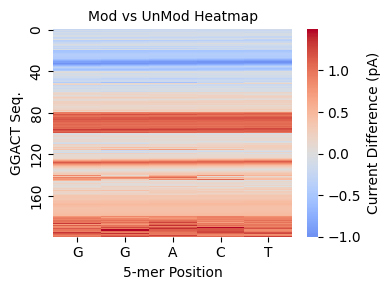

In [204]:
import seaborn as sns
import matplotlib.pyplot as plt
positions = ['G', 'G', 'A', 'C', 'T']
plt.figure(figsize=(4, 3))
sns.heatmap(
    diff_signals,
    cmap="coolwarm",  
    center=0,         
    xticklabels=positions,
    yticklabels=40,  
    cbar_kws={"label": "Current Difference (pA)"}
)
plt.xlabel("5-mer Position")
plt.ylabel("GGACT Seq.")
plt.title("Mod vs UnMod Heatmap",fontsize=10)
plt.tight_layout()
plt.savefig("f1_signal_diff_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [24]:
mod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m5c.tsv"
mod_signal, mod_mean, mod_std = load_predict_data(mod,data_length=100)
unmod = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.c.tsv"
unmod_signal, unmod_mean, unmod_std = load_predict_data(unmod,data_length=100)

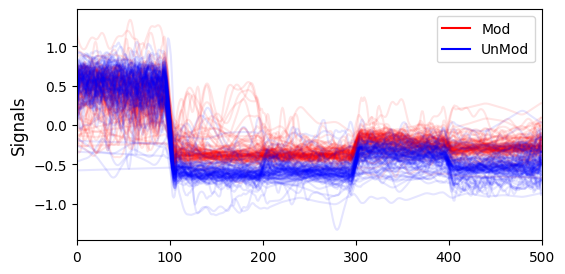

In [25]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
mod_signal = np.array(mod_signal)
unmod_signal = np.array(unmod_signal)
unmod_signal=unmod_signal.reshape(100,500)
mod_signal = mod_signal.reshape(100,500)
def savgol_smooth(signal, window_size=15, poly_order=3):
    return savgol_filter(signal, window_size, poly_order)

mod_signal = np.apply_along_axis(savgol_smooth, axis=1, arr=mod_signal)
unmod_signal = np.apply_along_axis(savgol_smooth, axis=1, arr=unmod_signal)
num_samples = mod_signal.shape[0]  
time_steps = mod_signal.shape[1]  
plt.figure(figsize=(6, 3))
for i in range(100):
    plt.plot(range(time_steps), mod_signal[i], color='red', alpha=0.1)
for i in range(100):
    plt.plot(range(time_steps), unmod_signal[i], color='blue', alpha=0.1)
plt.xlim(0,500)
plt.xlabel("",fontsize=12)
plt.ylabel("Signals",fontsize=12)
plt.title("")
red_line, = plt.plot([], [], color='red', label="Mod")  
blue_line, = plt.plot([], [], color='blue', label="UnMod") 
plt.legend(handles=[red_line, blue_line], loc="upper right") 
plt.savefig("/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/f1_signal_pa.pdf", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
